# DataLake - Jogos Olímpicos
- Aluno: Pedro Yutaro Mont Morency Nakamura
- Disciplina: Ciência de Dados
- Data: Março de 2026

## Descrição da Atividade:
Este notebook utiliza dados históricos das Olimpíadas (1896–2022) e dados
dos Jogos Olímpicos de Paris 2024 para consolidar o total de medalhas
por país, por meio da arquitetura por zonas.

Os dados foram obtidos das seguintes fontes:

- Base dos Dados – Histórico das Olimpíadas
- Kaggle – Paris 2024 Olympic Summer Games

## 1. Importações e Configurações:

Importação de módulos padrão

In [15]:
import sys
from pathlib import Path
from typing import Literal


Configuração de Path:

In [8]:
root = Path().absolute().parent.parent
sys.path.append(str(root))

Importação de módulos locais:

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src import CatalogManager
from src.pipeline_utils import save_and_catalog

### 1.1. Carregando Dados

In [10]:
catalog = CatalogManager()

In [11]:
src_integrated_medals = '../../silver/joins/integrated_medal_tally_1896_2024.parquet'

df_integrated_medals = pd.read_parquet(src_integrated_medals)

In [12]:
df_integrated_medals.head()

,country_noc,country,gold,silver,bronze,total,year,season,edition,edition_id
0,USA,United States,11,7,2,20,1896,Summer,1896 Summer Olympics,1
1,GRE,Greece,10,18,19,47,1896,Summer,1896 Summer Olympics,1
2,GER,Germany,6,5,2,13,1896,Summer,1896 Summer Olympics,1
3,FRA,France,5,4,2,11,1896,Summer,1896 Summer Olympics,1
4,GBR,Great Britain,2,3,2,7,1896,Summer,1896 Summer Olympics,1


In [14]:
df_integrated_medals.info()

<class 'pandas.DataFrame'>
RangeIndex: 1899 entries, 0 to 1898
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   country_noc  1899 non-null   str  
 1   country      1899 non-null   str  
 2   gold         1899 non-null   int64
 3   silver       1899 non-null   int64
 4   bronze       1899 non-null   int64
 5   total        1899 non-null   int64
 6   year         1899 non-null   int64
 7   season       1899 non-null   str  
 8   edition      1899 non-null   str  
 9   edition_id   1899 non-null   int64
dtypes: int64(6), str(4)
memory usage: 218.6 KB


In [ ]:
df_integrated_medals.season.value_counts()

season
Summer    1435
Winter     464
Name: count, dtype: int64

## 2. Processando Quadros de medalha por Estação

### 2.1 Função geradora de analises:

In [20]:
def generate_gold_analysis(
    df: pd.DataFrame,
    filename: str,
    src: str,
    description: str,
    output_path: str,
    catalog_manager: CatalogManager,
    observations: str,
    file_format: str,
    season_filter: Literal['Summer', 'Winter'] = None,
) -> pd.DataFrame:
  
  if season_filter:
    df_filtered = df[df['season'] == season_filter].copy()
  else:
    df_filtered = df.copy()

  df_country_group = df_filtered.groupby('country')[['gold', 'silver', 'bronze', 'total']].sum()
  df_grouped = df_country_group.sort_values(by='total', ascending=False)

  save_and_catalog(
    df=df_grouped,
    catalog_manager=catalog_manager,
    description=description,
    filename=filename,
    layer='gold',
    file_format=file_format,
    observations=observations,
    src=src,
    output_path=output_path
  )

  return df_grouped

### 2.2 Geração de quadros por estações:

In [ ]:
# Tabela de Medalhas de Summer
df_summer = generate_gold_analysis(
  season_filter='Summer',
  df=df_integrated_medals,
  output_path='./',
  filename='summer_medals',
  file_format='.csv',
  description='Quadro de medalhas - Jogos de Verão (1896 - 2024)',
  observations='Esse Dado foi gerado na camada gold, na análise de medalhas por estação, no contexto da geração de quadros de summer',
  src=src_integrated_medals,
  catalog_manager=catalog,
)

✅ Dataset summer_medals processado com sucesso na camada gold.


In [26]:
df_summer.head()

,gold,silver,bronze,total
country,,,,
United States,1110,885,786,2781
Russia,460,385,348,1193
Great Britain,305,345,342,992
France,247,283,307,837
Germany,249,277,298,824


In [22]:
# Tabela de Medalhas de Winter
df_winter = generate_gold_analysis(
  season_filter='Winter',
  df=df_integrated_medals,
  output_path='./',
  filename='winter_medals',
  file_format='.csv',
  description='Quadro de medalhas - Jogos de Inverno (1896 - 2024)',
  observations='Esse Dado foi gerado na camada gold, na análise de medalhas por estação, no contexto da geração de quadros de medalhas dos jogos de Inverno.',
  src=src_integrated_medals,
  catalog_manager=catalog,
)

✅ Dataset winter_medals processado com sucesso na camada gold.


In [27]:
df_winter.head()

,gold,silver,bronze,total
country,,,,
Norway,149,135,123,407
United States,125,128,101,354
Germany,118,113,76,307
Russia,95,81,90,266
Austria,74,91,94,259


In [23]:
# Tabela de Medalhas Totais
df_total = generate_gold_analysis(
  df=df_integrated_medals,
  output_path='./',
  filename='total_medals',
  file_format='.csv',
  description='Quadro de medalhas - Total Histórico (1896 - 2024)',
  observations='Esse Dado foi gerado na camada gold, na análise de medalhas por estação, no contexto da geração de quadros de medalhas históricas totais (todas as estações).',
  src=src_integrated_medals,
  catalog_manager=catalog,
)

✅ Dataset total_medals processado com sucesso na camada gold.


In [29]:
df_total.head()

,gold,silver,bronze,total
country,,,,
United States,1235,1013,887,3135
Russia,555,466,438,1459
Germany,367,390,374,1131
Great Britain,326,361,366,1053
France,303,334,378,1015


## 3. Geração de Gráficos e Dados Visuais:

### 3.1 Função geradora de gráficos 

In [ ]:
def plot_medals_ranking(
    df: pd.DataFrame,
    title: str,
    filename: str,
    n: int,
    savefig: bool,
    xlabel: str = 'Total de Medalhas',
    ylabel: str = 'Países',
    palette: str = 'viridis',
    figsize: tuple[int, int] = (12, 10),
    img_format: Literal['.png', 'jpeg'] = '.png'
):
  plt.figure(figsize=figsize)
  top_n = df.head(n).reset_index()

  sns.barplot(
    data=top_n,
    x='total',
    y='country',
    palette=palette,
    hue='country'
  )

  plt.title(title, fontsize=15)
  plt.xlabel(xlabel, fontsize=12)
  plt.ylabel(ylabel, fontsize=12)
  plt.grid(axis='x', linestyle='--', alpha=0.7)
  plt.tight_layout()

  filestr = f"{filename}.{img_format}"
  if savefig:
    plt.savefig(filestr)

  plt.show()


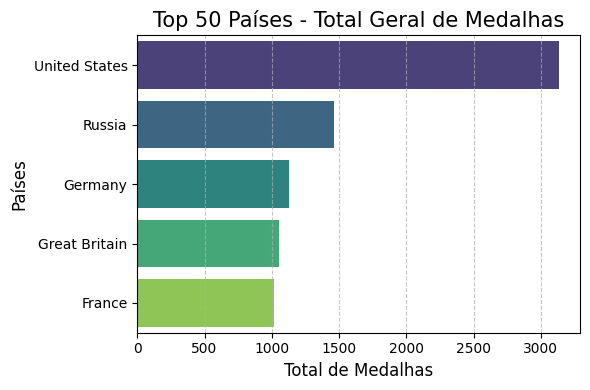

In [66]:
# Gráfico de Medalhas Totais
plot_medals_ranking(
  df=df_total,
  title='Top 50 Países - Total Geral de Medalhas',
  filename='plot_total_medals',
  n=5,
  savefig=False,
  figsize=(6, 4)
)

### 3.2 Gerando gráficos:

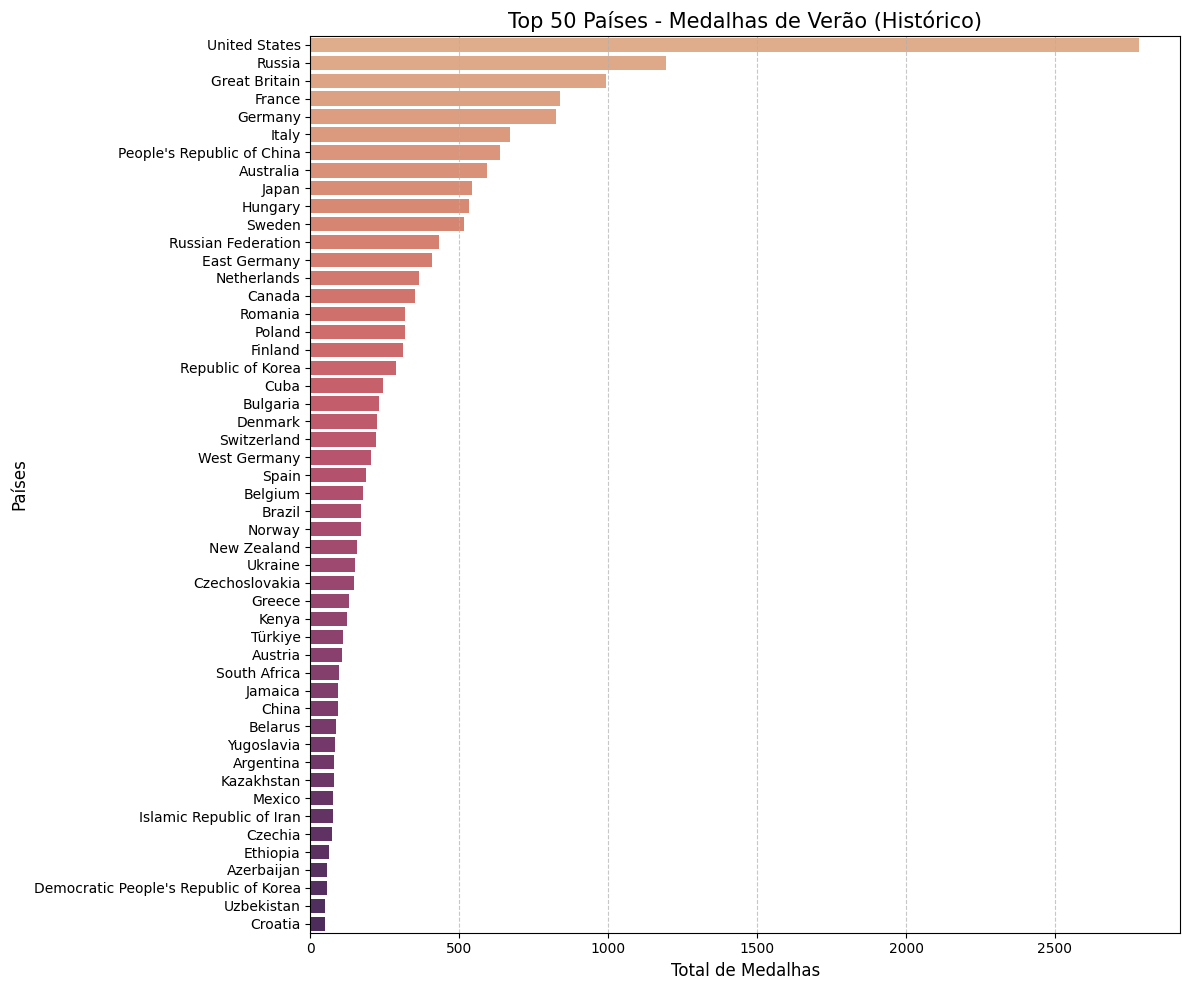

In [57]:
# Gráfico de Verão
plot_medals_ranking(
  df=df_summer,
  title='Top 50 Países - Medalhas de Verão (Histórico)',
  filename='plot_summer_medals',
  n=50,
  savefig=True,
  palette='flare'
)

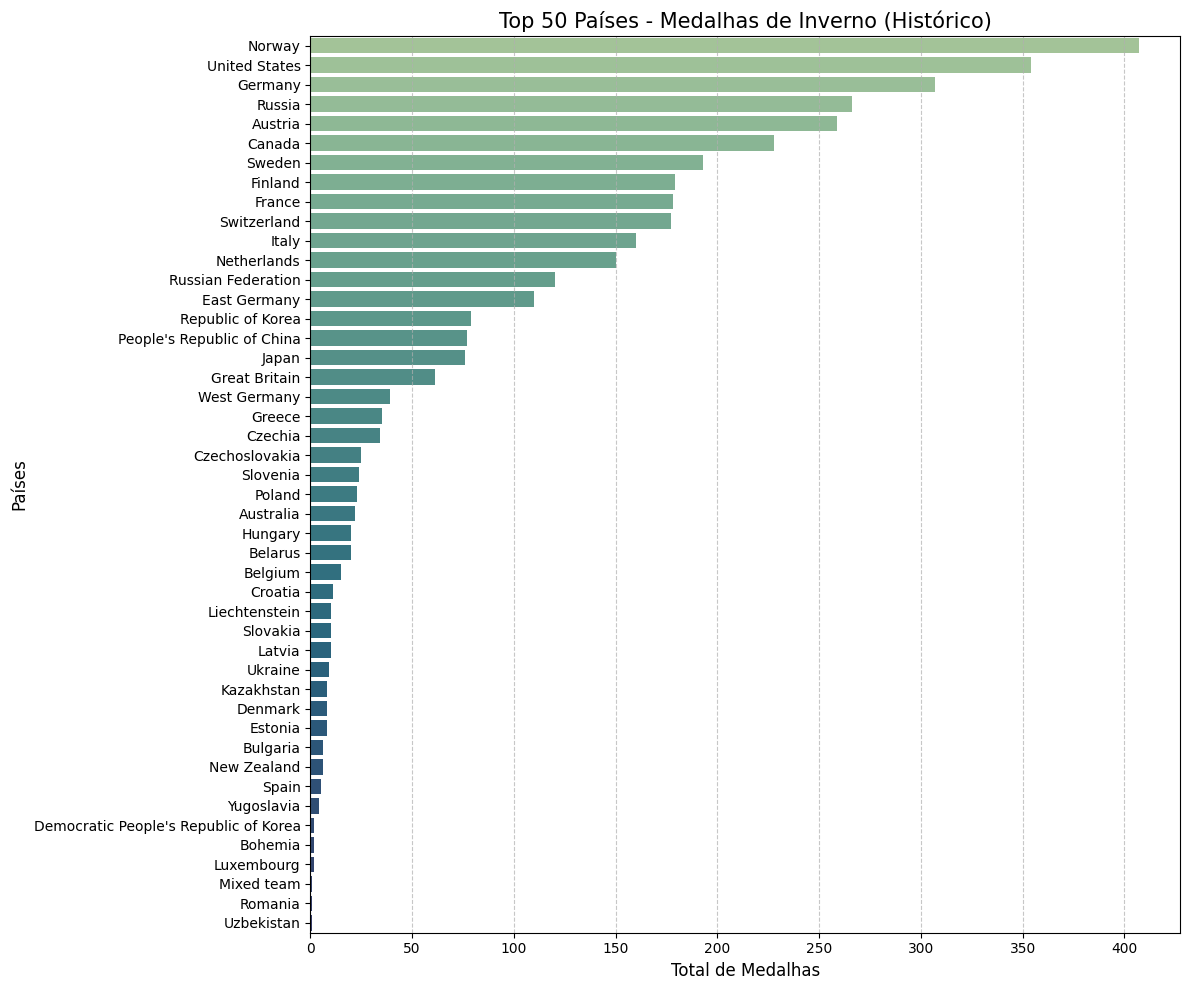

In [58]:
# Gráfico de Inverno
plot_medals_ranking(
  df=df_winter,
  title='Top 50 Países - Medalhas de Inverno (Histórico)',
  filename='plot_winter_medals',
  n=50,
  palette='crest',
  savefig=True
)

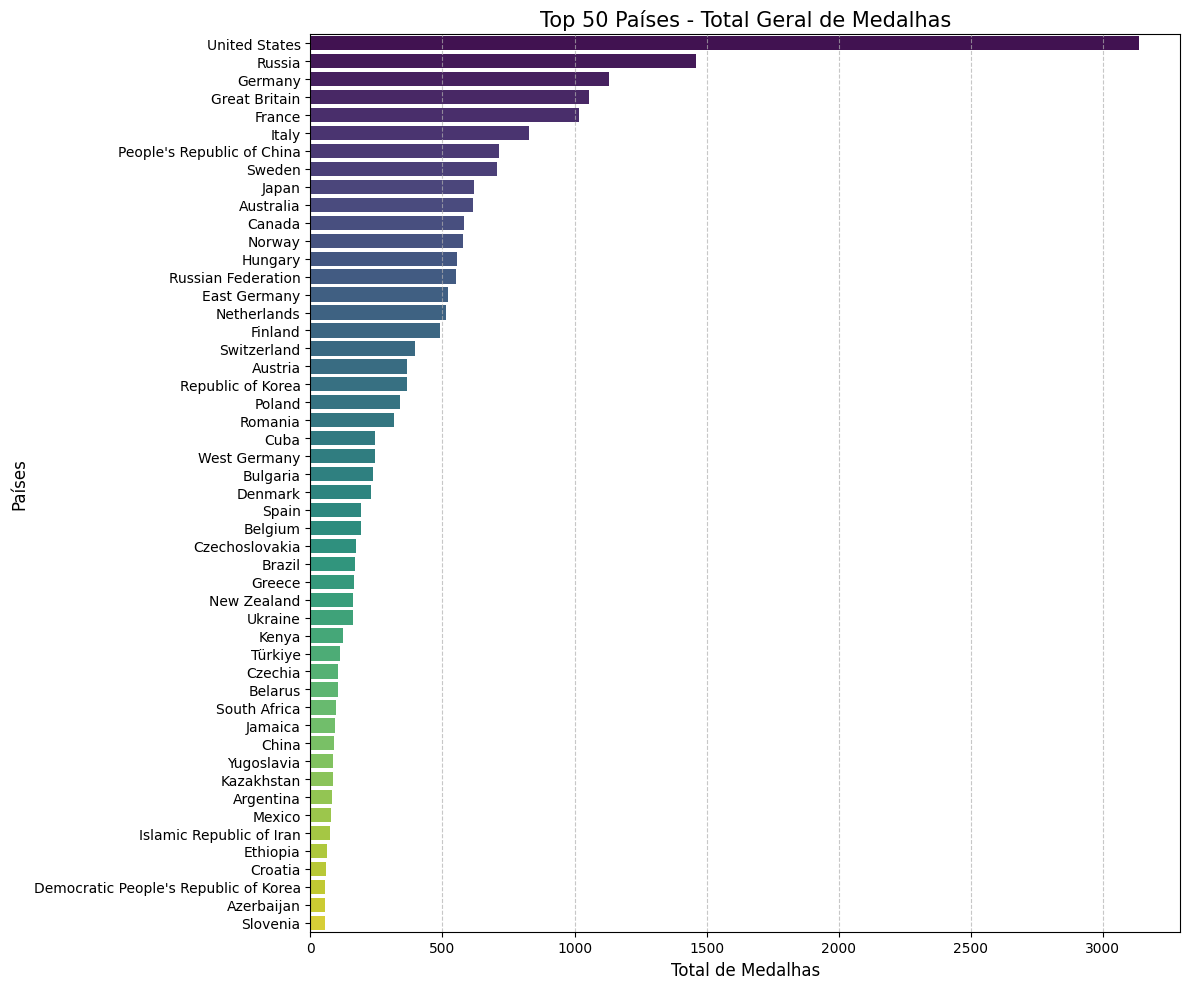

In [61]:
# Gráfico de Medalhas Totais
plot_medals_ranking(
  df=df_total,
  title='Top 50 Países - Total Geral de Medalhas',
  filename='plot_total_medals',
  n=50,
  savefig=True
)